<a href="https://colab.research.google.com/github/JeanLuc-Oudshoorn/Tiny_TFM_Iris/blob/main/TabICL_for_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TabICL Demo on a Tiny Machine Learning Problem

In this notebook, we will compare **TabICL** against two popular tabular ML baselines:

- **Random Forest**
- **LightGBM**

We will use the classic **Iris dataset**, which contains only **150 rows**. This makes it a useful toy example for a "low-data" setting where a pre-trained model may have a natural advantage.

The goal is to show how TabICL can be used in a familiar scikit-learn-style workflow:

1. Install the required libraries
2. Load the Iris dataset
3. Inspect and clean the data
4. Split into train and test sets
5. Train and predict with each model
6. Compare accuracy and confusion matrices

In [ ]:
# Install the required libraries.
# RandomForestClassifier comes from scikit-learn, while LightGBM is installed separately.

%pip install -q tabicl lightgbm scikit-learn pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.9/252.9 kB 16.2 MB/s eta 0:00:00


## Import libraries

We will use:

- `tabicl` for the TabICL model
- `lightgbm` for a gradient boosting baseline
- `sklearn` for the Iris dataset, Random Forest, train/test splitting, and evaluation
- `pandas` and `numpy` for data handling
- `matplotlib` for visualizing confusion matrices

The timing utilities from Python's standard library will be used to measure how long fitting and prediction take.

In [ ]:
import time
from typing import Any

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

from tabicl import TabICLClassifier

## Load the Iris dataset

The Iris dataset contains measurements from three Iris flower species:

- Setosa
- Versicolor
- Virginica

Each row has four numeric measurements:

- Sepal length
- Sepal width
- Petal length
- Petal width

The target is the Iris species.

In [ ]:
iris = load_iris(as_frame=True)

X = iris.data
y = iris.target

target_names = iris.target_names
feature_names = iris.feature_names

df = X.copy()
df['target'] = y
df['target_name'] = df['target'].map(dict(enumerate(target_names)))

print(f'Number of rows: {df.shape[0]}')
print(f'Number of features: {X.shape[1]}')
print(f'Classes: {list(target_names)}')

df.head()

Number of rows: 150
Number of features: 4
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Data inspection and cleaning

For a real-world tabular ML problem, this step would usually include:

- Checking for missing values
- Checking data types
- Looking for obvious data quality issues
- Encoding categorical variables
- Scaling numeric features if needed
- Creating domain-specific features

For Iris, very little cleaning is required. The dataset already consists of clean numeric features and a categorical target encoded as integers.

Also note that Random Forest and LightGBM are tree-based models, so feature scaling is not required. TabICL also includes built-in preprocessing for common tabular issues such as missing values, categorical columns, outliers, and feature normalization, but this Iris example does not need much preprocessing.

It is generally considered good practice to also perform some exploratory data analysis, such as plotting the distributions of variables against each other. This step has been skipped here for brevity.

In [ ]:
print('Data types:')
print(df.dtypes)

print('\nMissing values per column:')
print(df.isna().sum())

print('\nClass distribution:')
print(df['target_name'].value_counts())

print('\nFeature summary:')
df[feature_names].describe()

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
target_name           object
dtype: object

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
target_name          0
dtype: int64

Class distribution:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Feature summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Train/test split

The full dataset has only **150 rows**, so this is a genuinely tiny ML example.

We will keep **50 rows for testing** and use the remaining **100 rows for training**. This simulates a setting where only a small amount of labeled training data is available.

We use stratification so that the class proportions remain balanced in both train and test sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=50,
    random_state=42,
    stratify=y,
)

print(f'Train rows: {X_train.shape[0]}')
print(f'Test rows: {X_test.shape[0]}')

print('\nTrain class distribution:')
print(pd.Series(y_train).map(dict(enumerate(target_names))).value_counts())

print('\nTest class distribution:')
print(pd.Series(y_test).map(dict(enumerate(target_names))).value_counts())

Train rows: 100
Test rows: 50

Train class distribution:
target
setosa        34
virginica     33
versicolor    33
Name: count, dtype: int64

Test class distribution:
target
virginica     17
versicolor    17
setosa        16
Name: count, dtype: int64


## Define the models

We will compare three approaches:

1. **TabICL**  
   A tabular foundation model that uses in-context learning. We provide training data as context, and the model predicts test rows based on that context.

2. **Random Forest**  
   A strong classical baseline for small tabular datasets.

3. **LightGBM**  
   A popular gradient boosting library that is often highly competitive on tabular ML problems.

To keep the comparison simple and fast, we will not perform hyperparameter tuning. Each model gets one training run and one prediction run.

Note that the number of trees for the LightGBM model is reduced to prevent rampant overfitting.

In [ ]:
models: dict[str, Any] = {
    'TabICL': TabICLClassifier(),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        random_state=42,
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=20,
        random_state=42,
        verbose=-1,
    ),
}

## Train and predict

For each model, we will measure:

- Fit time
- Prediction time
- Accuracy

For TabICL, the timing interpretation is slightly different from Random Forest and LightGBM. TabICL's `fit()` step is lightweight because the model does not learn new model weights for this dataset. The in-context learning happens during `predict()`.

In [ ]:
results: list[dict[str, Any]] = []
predictions: dict[str, np.ndarray] = {}

for model_name, model in models.items():
    print(f'Running {model_name}...')

    fit_start_time = time.perf_counter()
    model.fit(X_train, y_train)
    fit_end_time = time.perf_counter()

    predict_start_time = time.perf_counter()
    y_pred = model.predict(X_test)
    predict_end_time = time.perf_counter()

    fit_time_seconds = fit_end_time - fit_start_time
    predict_time_seconds = predict_end_time - predict_start_time
    accuracy = accuracy_score(y_test, y_pred)

    predictions[model_name] = y_pred

    results.append(
        {
            'model': model_name,
            'fit_time_seconds': fit_time_seconds,
            'predict_time_seconds': predict_time_seconds,
            'accuracy': accuracy,
        }
    )

results_df = pd.DataFrame(results).sort_values(
    by='accuracy',
    ascending=False,
)

results_df

Running TabICL...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt:   0%|          | 0.00/110M [00:00<?, ?B/s]

Running Random Forest...
Running LightGBM...


,model,fit_time_seconds,predict_time_seconds,accuracy
0,TabICL,6.746783,1.747279,0.96
2,LightGBM,0.067579,0.003902,0.94
1,Random Forest,0.311498,0.013965,0.92


## Compare accuracy and runtime

The table below gives a compact comparison of the models.

Because this dataset is extremely small, timing numbers may be noisy. On such a tiny dataset, overhead from Python, package initialization, and hardware can dominate the actual ML computation.

The most meaningful metrics here are:

- Did the model work out of the box?
- How accurate was it with only 100 training rows?
- How simple was the modeling workflow?

In [ ]:
display_results_df = results_df.copy()

display_results_df['fit_time_ms'] = display_results_df['fit_time_seconds'] * 1_000
display_results_df['predict_time_ms'] = display_results_df['predict_time_seconds'] * 1_000

display_results_df = display_results_df[
    [
        'model',
        'accuracy',
        'fit_time_ms',
        'predict_time_ms',
    ]
]

display_results_df

,model,accuracy,fit_time_ms,predict_time_ms
0,TabICL,0.96,6746.783278,1747.279395
2,LightGBM,0.94,67.578708,3.902350
1,Random Forest,0.92,311.497747,13.965078


## Confusion matrices

Accuracy gives us one summary number, but a confusion matrix shows which classes are being confused with each other.

Rows represent the true class. Columns represent the predicted class.

For Iris, the Setosa class is usually easiest to classify. Most mistakes, if any, are usually between Versicolor and Virginica because those two classes overlap more in feature space.

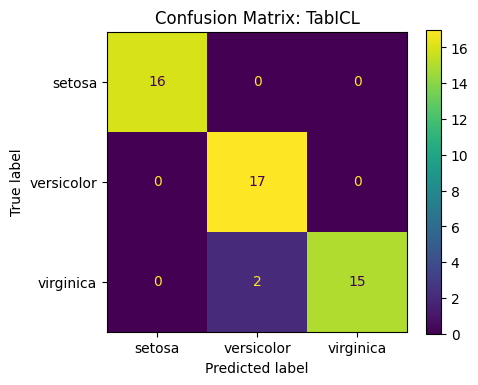

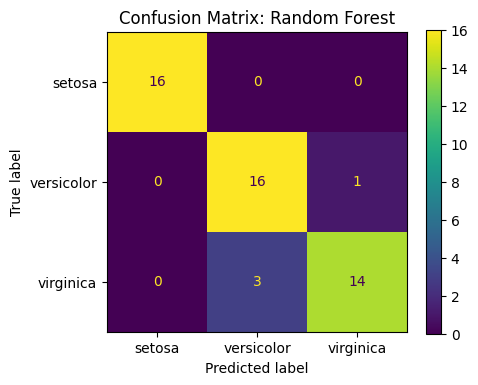

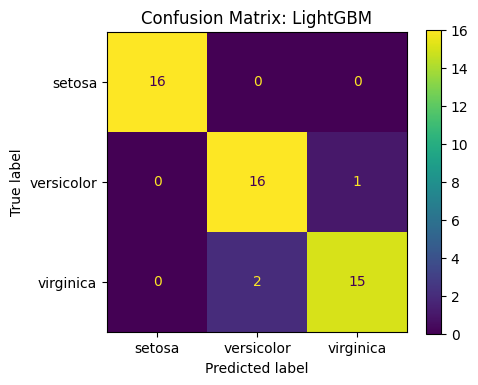

In [ ]:
for model_name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_names,
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, values_format='d')
    ax.set_title(f'Confusion Matrix: {model_name}')
    plt.tight_layout()
    plt.show()

## Final interpretation

This notebook demonstrates a small, low-data tabular classification workflow.

Key takeaways:

- The Iris dataset is tiny: only 150 rows in total.
- We trained with only 100 rows and tested on 50 rows.
- TabICL can be used through a familiar scikit-learn-style API.
- Random Forest and LightGBM provide strong classical tabular baselines.
- On tiny datasets, runtime measurements should be interpreted carefully because fixed overhead can dominate.
- Confusion matrices help reveal whether errors are concentrated between specific classes.

